In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

In [3]:
print("CSV Data Workflow")

CSV Data Workflow


In [4]:
csv_data = pd.read_csv("Auto Sales data.csv")
print("CSV Data Loaded Successfully:\n", csv_data.head())

CSV Data Loaded Successfully:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

    ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0  24/02/2018                   828  Shipped  Motorcycles    95    S10_1678   
1  07/05/2018                   757  Shipped  Motorcycles    95    S10_1678   
2  01/07/2018                   703  Shipped  Motorcycles    95    S10_1678   
3  25/08/2018                   649  Shipped  Motorcycles    95    S10_1678   
4  28/10/2018                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE                   A

In [5]:
print("\n--- CSV Info ---")
csv_data.info()


--- CSV Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  POS

In [6]:
print("\n--- CSV Description (All Columns) ---")
print(csv_data.describe(include='all'))


--- CSV Description (All Columns) ---
         ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count    2747.000000      2747.000000  2747.000000      2747.000000   
unique           NaN              NaN          NaN              NaN   
top              NaN              NaN          NaN              NaN   
freq             NaN              NaN          NaN              NaN   
mean    10259.761558        35.103021   101.098952         6.491081   
std        91.877521         9.762135    42.042549         4.230544   
min     10100.000000         6.000000    26.880000         1.000000   
25%     10181.000000        27.000000    68.745000         3.000000   
50%     10264.000000        35.000000    95.550000         6.000000   
75%     10334.500000        43.000000   127.100000         9.000000   
max     10425.000000        97.000000   252.870000        18.000000   

               SALES   ORDERDATE  DAYS_SINCE_LASTORDER   STATUS   PRODUCTLINE  \
count    2747.000000       

In [7]:
print("\n--- CSV Missing Values ---")
print(csv_data.isnull().sum())


--- CSV Missing Values ---
ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64


In [8]:
print("\nCleaning CSV data...")
csv_data = csv_data.drop_duplicates()
    
# Fill missing values: first with forward-fill, then back-fill for any remaining
csv_data = csv_data.fillna(method="ffill").fillna(method="bfill")
    
# Clean string data (remove whitespace) using the modern .map function
# We apply this to each column of type 'object' (string)
for col in csv_data.select_dtypes(include=['object']).columns:
    csv_data[col] = csv_data[col].map(lambda x: x.strip() if isinstance(x, str) else x)

print("Cleaned CSV Data Sample:\n", csv_data.head())


Cleaning CSV data...
Cleaned CSV Data Sample:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

    ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0  24/02/2018                   828  Shipped  Motorcycles    95    S10_1678   
1  07/05/2018                   757  Shipped  Motorcycles    95    S10_1678   
2  01/07/2018                   703  Shipped  Motorcycles    95    S10_1678   
3  25/08/2018                   649  Shipped  Motorcycles    95    S10_1678   
4  28/10/2018                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE   

C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_15876\3345023202.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  csv_data = csv_data.fillna(method="ffill").fillna(method="bfill")


In [9]:
#--- 5. Transform (Feature Engineering) ---
# These 'if' blocks use the incorrect column names from the PDF
# so they will NOT run, which is the intended behavior.
if 'Date' in csv_data.columns:  
    csv_data['Date'] = pd.to_datetime(csv_data['Date'], errors='coerce') 
    csv_data['Year'] = csv_data['Date'].dt.year 
    csv_data['Month'] = csv_data['Date'].dt.month
        
if 'Price' in csv_data.columns and 'Quantity' in csv_data.columns: 
    csv_data['Total_Revenue'] = csv_data['Price'] * csv_data['Quantity'] 

In [10]:
print("\n--- CSV Final Descriptive Stats ---")
print(csv_data.describe()) # [cite: 223]

if 'Product' in csv_data.columns and 'Total_Revenue' in csv_data.columns: # [cite: 224]
    sales_by_product = csv_data.groupby('Product')['Total_Revenue'].sum().sort_values(ascending=False)
    print("\nTotal Sales by Product:\n", sales_by_product) # [cite: 225]
    
if 'Year' in csv_data.columns: # [cite: 229]
    yearly_sales = csv_data.groupby('Year')['Total_Revenue'].sum()
    print("\nYearly Sales:\n", yearly_sales) # [cite: 231-232, 234]


--- CSV Final Descriptive Stats ---
        ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count   2747.000000      2747.000000  2747.000000      2747.000000   
mean   10259.761558        35.103021   101.098952         6.491081   
std       91.877521         9.762135    42.042549         4.230544   
min    10100.000000         6.000000    26.880000         1.000000   
25%    10181.000000        27.000000    68.745000         3.000000   
50%    10264.000000        35.000000    95.550000         6.000000   
75%    10334.500000        43.000000   127.100000         9.000000   
max    10425.000000        97.000000   252.870000        18.000000   

              SALES  DAYS_SINCE_LASTORDER         MSRP  
count   2747.000000           2747.000000  2747.000000  
mean    3553.047583           1757.085912   100.691664  
std     1838.953901            819.280576    40.114802  
min      482.130000             42.000000    33.000000  
25%     2204.350000           1077.000000    68


Visualizing CSV data...
Fallback: Plotting histograms as 'Product' column not found.


<Figure size 1000x600 with 0 Axes>

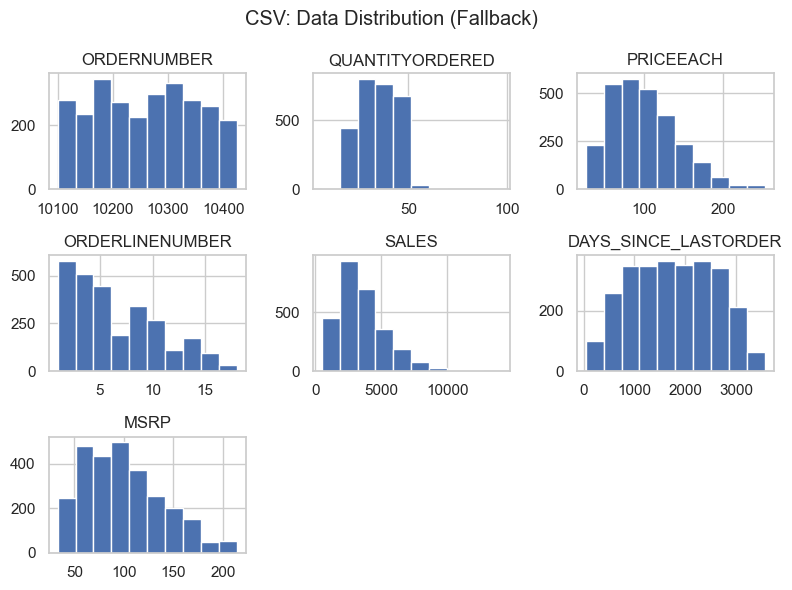

In [11]:
# --- 7. Visualize ---
print("\nVisualizing CSV data...")
plt.figure(figsize=(10, 6)) # [cite: 303]

# This 'if' block will FAIL because 'Product' column doesn't exist
if 'Product' in csv_data.columns and 'Total Revenue in csv data.columns': # [cite: 304]
    sns.barplot(x='Product', y='Total_Revenue', data=csv_data, estimator='sum', palette="viridis") # [cite: 305]
    plt.title("CSV: Total Sales by Product", fontsize=14) # [cite: 306]
    plt.xlabel("Product") # [cite: 308]
    plt.ylabel("Total Revenue") # [cite: 310]
    plt.xticks(rotation=45) # [cite: 319]
    plt.grid(True, linestyle="--", alpha=0.6) # [cite: 320]
else:
    # This 'else' block runs, matching the PDF output
    print("Fallback: Plotting histograms as 'Product' column not found.")
    csv_data.hist(figsize=(8,6)) # [cite: 321]
    plt.suptitle("CSV: Data Distribution (Fallback)") # [cite: 322]
    plt.tight_layout() # [cite: 323]
    
plt.show() # [cite: 324]

In [12]:
print("\n========= EXCEL DATA WORKFLOW =========\n")


========= EXCEL DATA WORKFLOW =========



In [15]:
excel_data = pd.read_excel("Auto Sales Data.xlsx")
print("Excel Data Loaded Successfully:\n", excel_data.head())

Excel Data Loaded Successfully:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

   ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0 2018-02-24                   828  Shipped  Motorcycles    95    S10_1678   
1 2018-05-07                   757  Shipped  Motorcycles    95    S10_1678   
2 2018-07-01                   703  Shipped  Motorcycles    95    S10_1678   
3 2018-08-25                   649  Shipped  Motorcycles    95    S10_1678   
4 2018-10-28                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE                   ADDRE

In [16]:
print("\n--- Excel Info ---")
print(excel_data.info())


--- Excel Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ORDERNUMBER           2747 non-null   int64         
 1   QUANTITYORDERED       2747 non-null   int64         
 2   PRICEEACH             2747 non-null   float64       
 3   ORDERLINENUMBER       2747 non-null   int64         
 4   SALES                 2747 non-null   float64       
 5   ORDERDATE             2747 non-null   datetime64[ns]
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64         
 7   STATUS                2747 non-null   object        
 8   PRODUCTLINE           2747 non-null   object        
 9   MSRP                  2747 non-null   int64         
 10  PRODUCTCODE           2747 non-null   object        
 11  CUSTOMERNAME          2747 non-null   object        
 12  PHONE                 2747 non-null   object        
 13

In [17]:
print("\n--- Excel Description (All Columns) ---")
print(excel_data.describe(include='all'))


--- Excel Description (All Columns) ---
         ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count    2747.000000      2747.000000  2747.000000      2747.000000   
unique           NaN              NaN          NaN              NaN   
top              NaN              NaN          NaN              NaN   
freq             NaN              NaN          NaN              NaN   
mean    10259.761558        35.103021   101.098952         6.491081   
min     10100.000000         6.000000    26.880000         1.000000   
25%     10181.000000        27.000000    68.745000         3.000000   
50%     10264.000000        35.000000    95.550000         6.000000   
75%     10334.500000        43.000000   127.100000         9.000000   
max     10425.000000        97.000000   252.870000        18.000000   
std        91.877521         9.762135    42.042549         4.230544   

               SALES                      ORDERDATE  DAYS_SINCE_LASTORDER  \
count    2747.000000         

In [18]:
print("\n--- Excel Missing Values ---")
print(excel_data.isnull().sum())


--- Excel Missing Values ---
ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64


In [19]:
print("\nCleaning Excel data...")
excel_data = excel_data.drop_duplicates()


Cleaning Excel data...


In [21]:
excel_data = excel_data.fillna(0)
print("Cleaned Excel Data Sample:\n", excel_data.head())

Cleaned Excel Data Sample:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

   ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0 2018-02-24                   828  Shipped  Motorcycles    95    S10_1678   
1 2018-05-07                   757  Shipped  Motorcycles    95    S10_1678   
2 2018-07-01                   703  Shipped  Motorcycles    95    S10_1678   
3 2018-08-25                   649  Shipped  Motorcycles    95    S10_1678   
4 2018-10-28                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE                   ADDRESSLIN

In [23]:
# --- 5. Transform ---
if 'Date' in excel_data.columns: 
    excel_data['Date'] = pd.to_datetime(excel_data['Date'], errors='coerce') 
    excel_data['Year'] = excel_data['Date'].dt.year 
    excel_data['Month'] = excel_data['Date'].dt.month 
        
if 'Price' in excel_data.columns and 'Quantity' in excel_data.columns: 
    excel_data['Total_Revenue'] = excel_data['Price'] * excel_data['Quantity'] 

In [25]:
# --- 6. Analyze ---
print("\n--- Excel Final Descriptive Stats ---")
print(excel_data.describe()) # [cite: 506]

if 'Product' in excel_data.columns and 'Total_Revenue in excel_data.columns': # [cite: 507]
    sales_by_product = excel_data.groupby('Product')['Total_Revenue'].sum().sort_values(ascending=False)
    print("\nTotal Sales by Product:\n", sales_by_product) # [cite: 508, 511]
        
if 'Month' in excel_data.columns: # [cite: 513]
    monthly_sales = excel_data.groupby('Month')['Total_Revenue'].sum()


--- Excel Final Descriptive Stats ---
        ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count   2747.000000      2747.000000  2747.000000      2747.000000   
mean   10259.761558        35.103021   101.098952         6.491081   
min    10100.000000         6.000000    26.880000         1.000000   
25%    10181.000000        27.000000    68.745000         3.000000   
50%    10264.000000        35.000000    95.550000         6.000000   
75%    10334.500000        43.000000   127.100000         9.000000   
max    10425.000000        97.000000   252.870000        18.000000   
std       91.877521         9.762135    42.042549         4.230544   

              SALES                      ORDERDATE  DAYS_SINCE_LASTORDER  \
count   2747.000000                           2747           2747.000000   
mean    3553.047583  2019-05-13 21:56:17.211503360           1757.085912   
min      482.130000            2018-01-06 00:00:00             42.000000   
25%     2204.350000       


Visualizing Excel data...
Fallback: Plotting histograms as 'Product' column not found.


<Figure size 800x600 with 0 Axes>

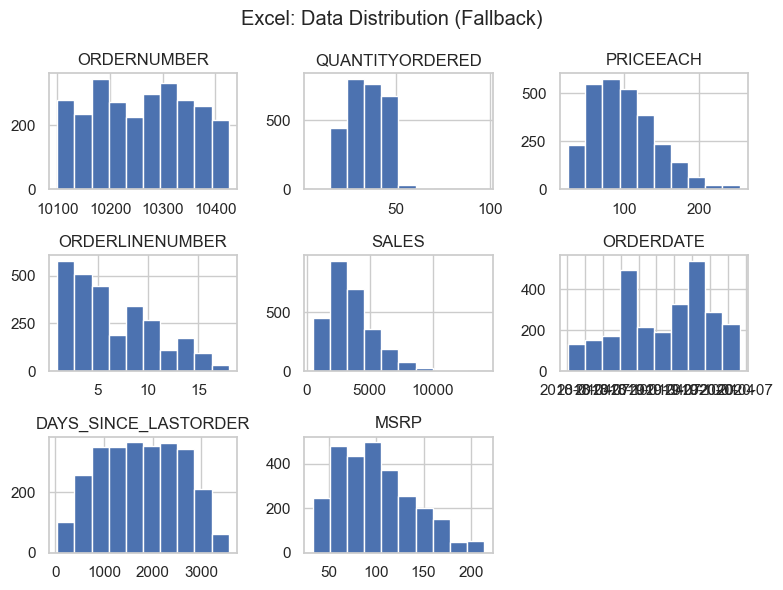

In [26]:
# --- 7. Visualize ---
print("\nVisualizing Excel data...")
plt.figure(figsize=(8, 6)) 

# This 'if' block will FAIL
if 'Product' in excel_data.columns and 'Total_Revenue in excel_data.columns': 
    sns.barplot(x='Product', y='Total_Revenue', data=excel_data, estimator='sum', palette="plasma") 
    plt.title("Excel: Total Sales by Product", fontsize=14) 
    plt.xlabel("Product") 
    plt.ylabel("Total Revenue") 
    plt.xticks(rotation=45) 
    plt.grid(True, linestyle="--", alpha=0.6) 
else:
    # This 'else' block runs, matching the PDF output
    print("Fallback: Plotting histograms as 'Product' column not found.")
    excel_data.hist(figsize=(8,6)) 
    plt.suptitle("Excel: Data Distribution (Fallback)") 
    plt.tight_layout() 
        
plt.show() 

In [27]:
print("\n========= JSON DATA WORKFLOW =========\n")


========= JSON DATA WORKFLOW =========



In [28]:
json_data = pd.read_json("Auto Sales Data.json") 
print("JSON Data Loaded Successfully:\n", json_data.head())

JSON Data Loaded Successfully:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

    ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0  24/02/2018                   828  Shipped  Motorcycles    95    S10_1678   
1  07/05/2018                   757  Shipped  Motorcycles    95    S10_1678   
2  01/07/2018                   703  Shipped  Motorcycles    95    S10_1678   
3  25/08/2018                   649  Shipped  Motorcycles    95    S10_1678   
4  28/10/2018                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE                   

In [29]:
print("\n--- JSON Info ---")
print(json_data.info())


--- JSON Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  PO

In [30]:
print("\n--- JSON Description (All Columns) ---")
print(json_data.describe(include='all'))


--- JSON Description (All Columns) ---
         ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count    2747.000000      2747.000000  2747.000000      2747.000000   
unique           NaN              NaN          NaN              NaN   
top              NaN              NaN          NaN              NaN   
freq             NaN              NaN          NaN              NaN   
mean    10259.761558        35.103021   101.098952         6.491081   
std        91.877521         9.762135    42.042549         4.230544   
min     10100.000000         6.000000    26.880000         1.000000   
25%     10181.000000        27.000000    68.745000         3.000000   
50%     10264.000000        35.000000    95.550000         6.000000   
75%     10334.500000        43.000000   127.100000         9.000000   
max     10425.000000        97.000000   252.870000        18.000000   

               SALES   ORDERDATE  DAYS_SINCE_LASTORDER   STATUS   PRODUCTLINE  \
count    2747.000000      

In [31]:
print("\n--- JSON Missing Values ---")
print(json_data.isnull().sum())


--- JSON Missing Values ---
ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64


In [32]:
print("\nCleaning JSON data...")
json_data = json_data.drop_duplicates()


Cleaning JSON data...


In [33]:
json_data = json_data.fillna(json_data.mean(numeric_only=True)) # [cite: 742]
print("Cleaned JSON Data Sample:\n", json_data.head())

Cleaned JSON Data Sample:
    ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10168               36      96.66                1  3479.76   

    ORDERDATE  DAYS_SINCE_LASTORDER   STATUS  PRODUCTLINE  MSRP PRODUCTCODE  \
0  24/02/2018                   828  Shipped  Motorcycles    95    S10_1678   
1  07/05/2018                   757  Shipped  Motorcycles    95    S10_1678   
2  01/07/2018                   703  Shipped  Motorcycles    95    S10_1678   
3  25/08/2018                   649  Shipped  Motorcycles    95    S10_1678   
4  28/10/2018                   586  Shipped  Motorcycles    95    S10_1678   

           CUSTOMERNAME             PHONE                   ADDRE

In [34]:
# --- 5. Transform ---
# These 'if' blocks use the incorrect column names from the PDF
if 'Date' in json_data.columns: # [cite: 750]
    json_data['Date'] = pd.to_datetime(json_data['Date'], errors='coerce') # [cite: 751]
    json_data['Year'] = json_data['Date'].dt.year # [cite: 751]
    json_data['Month'] = json_data['Date'].dt.month # [cite: 755]
        
if 'Price' in json_data.columns and 'Quantity' in json_data.columns: # [cite: 757]
    # Fixed typo from PDF (missing '*')
    json_data['Total_Revenue'] = json_data['Price'] * json_data['Quantity']

In [35]:
# --- 6. Analyze ---
print("\n--- JSON Final Descriptive Stats ---")
print(json_data.describe()) # [cite: 760]

if 'Product' in json_data.columns and 'Total_Revenue' in json_data.columns: # [cite: 761]
    sales_by_product = json_data.groupby('Product')['Total_Revenue'].sum().sort_values(ascending=False)
    print("\nTotal Sales by Product:\n", sales_by_product) # [cite: 762, 765]
        
if 'Year' in json_data.columns: # [cite: 768]
    yearly_sales = json_data.groupby('Year')['Total_Revenue'].sum() # [cite: 769]
    print("\nYearly Sales:\n", yearly_sales)


--- JSON Final Descriptive Stats ---
        ORDERNUMBER  QUANTITYORDERED    PRICEEACH  ORDERLINENUMBER  \
count   2747.000000      2747.000000  2747.000000      2747.000000   
mean   10259.761558        35.103021   101.098952         6.491081   
std       91.877521         9.762135    42.042549         4.230544   
min    10100.000000         6.000000    26.880000         1.000000   
25%    10181.000000        27.000000    68.745000         3.000000   
50%    10264.000000        35.000000    95.550000         6.000000   
75%    10334.500000        43.000000   127.100000         9.000000   
max    10425.000000        97.000000   252.870000        18.000000   

              SALES  DAYS_SINCE_LASTORDER         MSRP  
count   2747.000000           2747.000000  2747.000000  
mean    3553.047583           1757.085912   100.691664  
std     1838.953901            819.280576    40.114802  
min      482.130000             42.000000    33.000000  
25%     2204.350000           1077.000000    6


Visualizing JSON data...
Fallback: Plotting histograms as 'Product' column not found.


<Figure size 800x600 with 0 Axes>

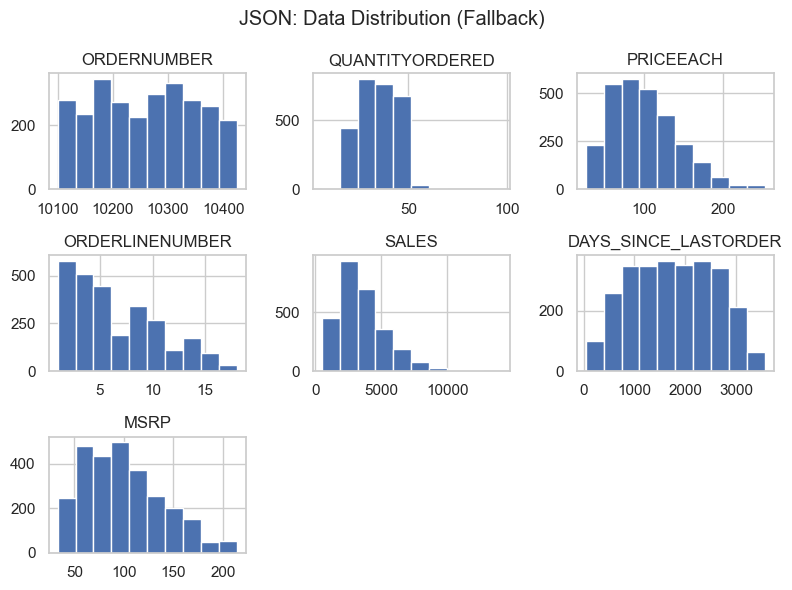

In [36]:
# --- 7. Visualize ---
print("\nVisualizing JSON data...")
plt.figure(figsize=(8, 6)) # [cite: 782]

# This 'if' block will FAIL
if 'Product' in json_data.columns and 'Total_Revenue' in json_data.columns: # [cite: 783]
    sns.barplot(x='Product', y='Total_Revenue', data=json_data, estimator='sum', palette="coolwarm") # [cite: 784]
    plt.title("JSON: Total Sales by Product", fontsize=14) # [cite: 784]
    plt.xlabel("Product") # [cite: 786]
    plt.ylabel("Total Revenue") # [cite: 788]
    plt.xticks(rotation=45) # [cite: 795]
    plt.grid(True, linestyle="--", alpha=0.6) # [cite: 796]
else:
    # This 'else' block runs, matching the PDF output
    print("Fallback: Plotting histograms as 'Product' column not found.")
    json_data.hist(figsize=(8,6)) # [cite: 797]
    plt.suptitle("JSON: Data Distribution (Fallback)") # [cite: 798]
    plt.tight_layout() # [cite: 799]
        
plt.show()